In [1]:
import numpy as np
import matplotlib.pyplot as plt
from inchworm import Inchworm

# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    """
    Bath correlation function alpha(t).
    Supports scalar t or 1D array t (returns same shape).
    """
    t_arr = np.asarray(t)
    t1 = np.atleast_1d(t_arr).astype(float)
    phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    return out[0] if t_arr.ndim == 0 else out

In [2]:
tmax = 5.0 / Delta
N_steps = 50
N_trunc = 3
N_MC_samples = 1000

/Users/maczhuo/Softwares/miniconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/maczhuo/Softwares/miniconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


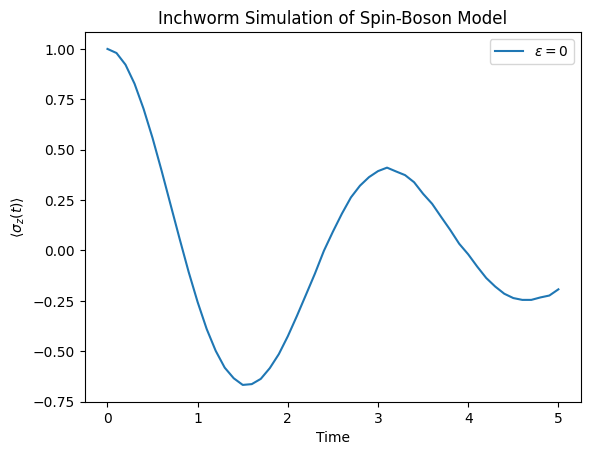

In [3]:
# spin-boson model parameters with eps = 0
eps = 0
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = Delta*sx + eps*sz
Os = sz
Ws = sz
rhos = np.array([[1, 0], [0, 0]], dtype=complex)

inchworm_solver = Inchworm(
    Hs = Hs,
    Ws = Ws,
    tmax = tmax,
    N_steps = N_steps,
    bath_corr = bath_corr,
    N_trunc = N_trunc,
    N_MC_samples = N_MC_samples   
)

result = inchworm_solver.inchworm_step(Os, rhos)

time_points = np.linspace(0, tmax, N_steps+1)
plt.plot(time_points, np.real_if_close(result), label=r'$\epsilon=0$')
plt.xlabel('Time')
plt.ylabel(r'$\langle \sigma_z(t) \rangle$')
plt.title('Inchworm Simulation of Spin-Boson Model')
plt.legend()
plt.show()

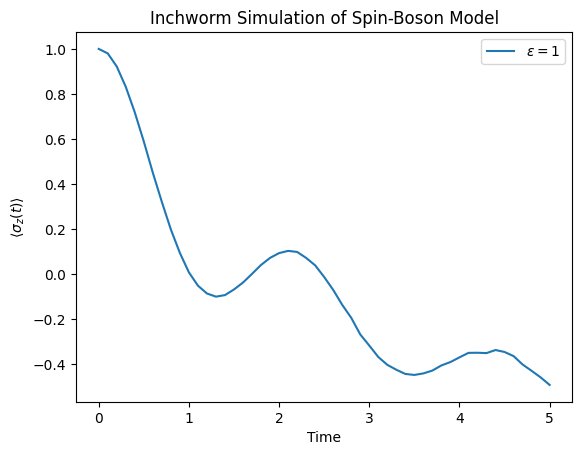

In [4]:
# spin-boson model parameters with eps = 1
eps = 1 * Delta
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = Delta*sx + eps*sz
Os = sz
Ws = sz
rhos = np.array([[1, 0], [0, 0]], dtype=complex)

inchworm_solver = Inchworm(
    Hs = Hs,
    Ws = Ws,
    tmax = tmax,
    N_steps = N_steps,
    bath_corr = bath_corr,
    N_trunc = N_trunc,
    N_MC_samples = N_MC_samples   
)

result = inchworm_solver.inchworm_step(Os, rhos)

time_points = np.linspace(0, tmax, N_steps+1)
plt.plot(time_points, np.real_if_close(result), label=r'$\epsilon=1$')
plt.xlabel('Time')
plt.ylabel(r'$\langle \sigma_z(t) \rangle$')
plt.title('Inchworm Simulation of Spin-Boson Model')
plt.legend()
plt.show()

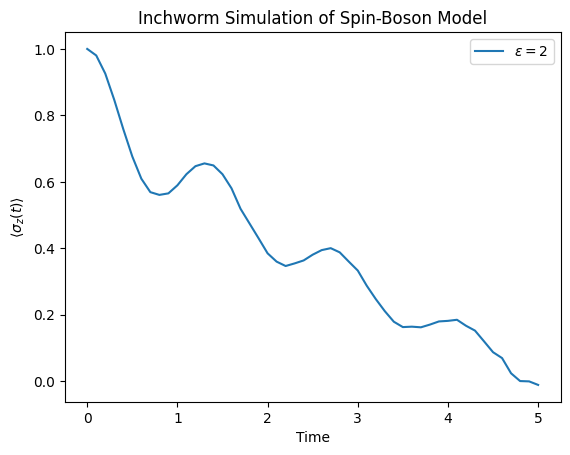

In [5]:
# spin-boson model parameters with eps = 2
eps = 2 * Delta
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = Delta*sx + eps*sz
Os = sz
Ws = sz
rhos = np.array([[1, 0], [0, 0]], dtype=complex)

inchworm_solver = Inchworm(
    Hs = Hs,
    Ws = Ws,
    tmax = tmax,
    N_steps = N_steps,
    bath_corr = bath_corr,
    N_trunc = N_trunc,
    N_MC_samples = N_MC_samples   
)

result = inchworm_solver.inchworm_step(Os, rhos)

time_points = np.linspace(0, tmax, N_steps+1)
plt.plot(time_points, np.real_if_close(result), label=r'$\epsilon=2$')
plt.xlabel('Time')
plt.ylabel(r'$\langle \sigma_z(t) \rangle$')
plt.title('Inchworm Simulation of Spin-Boson Model')
plt.legend()
plt.show()